# Visa For Lisa — who will accept a personal loan?

**Client:** Galaxy Bank, marketing leadership (CEO attending).
**Question:** which of our deposit customers should we offer a personal loan to, so that the
campaign converts far better than last year's ~9 %?

**Plan** (the five stages of the brief):

1. Data collecting / cleaning
2. Data exploration
3. Data visualization
4. Machine learning — a linear-regression baseline, then real classifiers
5. Communication — what happens to the conversion rate, and what could go wrong

Production-ready code lives next to this notebook in `loan_model.py` (see section 6).

## 1. Data collecting / cleaning

In [ ]:
from pathlib import Path
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
SEED = 42

DATA_URL = "https://storage.googleapis.com/qwasar-public/track-ds/Visa_For_Lisa_Loan_Modelling.csv"
DATA = Path("data/Visa_For_Lisa_Loan_Modelling.csv")
if not DATA.exists():
    DATA.parent.mkdir(exist_ok=True)
    DATA.write_bytes(requests.get(DATA_URL, timeout=60).content)

raw = pd.read_csv(DATA)
print(raw.shape)
raw.head()

(5000, 14)


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


The file is small (5 000 customers, 14 columns) and typed cleanly. Three things need cleaning:

- `ID` is a row identifier, `ZIP Code` is a 5-digit label with ~460 distinct values — neither is a feature for a model this size, so both go.
- `Experience` has negative values (a known data-entry artefact in this dataset: the sign was lost). We take the absolute value.
- `Personal Loan` is the target; everything else is a candidate feature.

In [ ]:
print("missing values:", raw.isna().sum().sum())
print("duplicated rows:", raw.duplicated().sum())
print("negative Experience rows:", (raw["Experience"] < 0).sum())

df = raw.drop(columns=["ID", "ZIP Code"]).copy()
df["Experience"] = df["Experience"].abs()
TARGET = "Personal Loan"
FEATURES = [c for c in df.columns if c != TARGET]
df.describe().T

missing values: 0
duplicated rows: 0
negative Experience rows: 52


,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.134600,11.415189,0.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0
CD Account,5000.0,0.060400,0.238250,0.0,0.0,0.0,0.0,1.0


## 2. Data exploration

In [ ]:
rate = df[TARGET].mean()
print(f"Loan acceptance rate: {rate:.1%}  ({df[TARGET].sum()} of {len(df)} customers)")

Loan acceptance rate: 9.6%  (480 of 5000 customers)


9.6 % acceptance — this *is* last year's campaign the brief mentions ("over 9 %"). That is our
baseline: mailing everybody converts about 1 in 10. The question is whether the data lets us
find the 1 in 10 before we spend the marketing budget.

Which customer attributes move that rate?

In [ ]:
cat_cols = ["Education", "Family", "Securities Account", "CD Account", "Online", "CreditCard"]
summary = pd.concat(
    {c: df.groupby(c)[TARGET].agg(rate="mean", n="size") for c in cat_cols}, names=["feature", "value"]
)
summary.style.format({"rate": "{:.1%}"}).background_gradient(subset=["rate"], cmap="Reds")

In [ ]:
num_cols = ["Age", "Experience", "Income", "CCAvg", "Mortgage"]
df.groupby(TARGET)[num_cols].median().rename(index={0: "declined", 1: "accepted"})

,Age,Experience,Income,CCAvg,Mortgage
Personal Loan,,,,,
declined,45.0,20.0,59.0,1.4,0.0
accepted,45.0,20.0,142.5,3.8,0.0


Two signals dominate already:

- **Income and credit-card spend** — accepters earn roughly 2.5× more (median 142 k vs 59 k) and spend 2.5× more per month.
- **Having a CD account** — 46 % of CD-account holders accepted vs 7 % of the others. That's a 6× lift from a single flag.

Education matters too (graduate / professional degrees accept 3× more than undergraduates), while
`Online` and `CreditCard` barely move the needle.

## 3. Data visualization

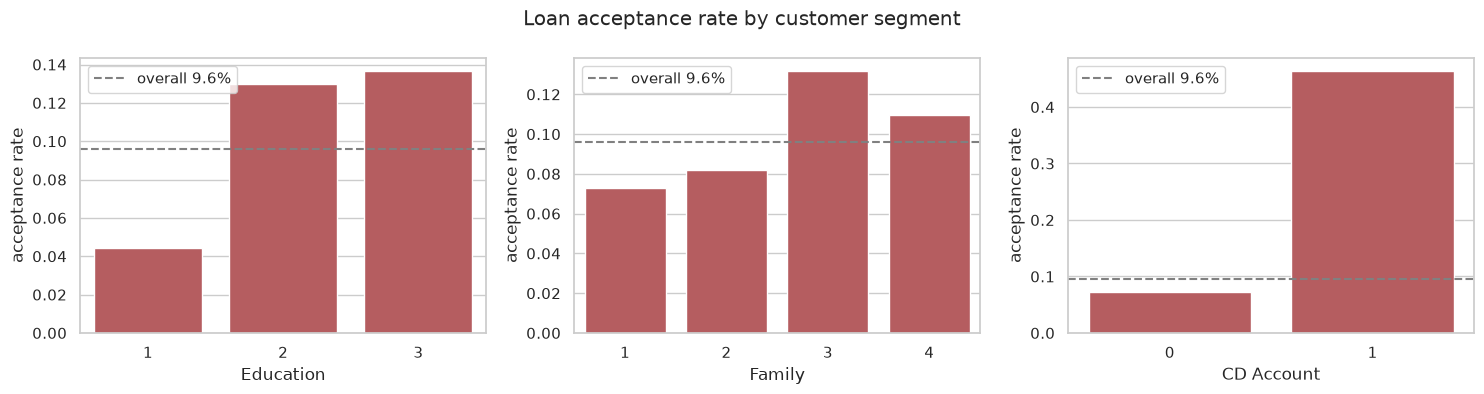

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Education", "Family", "CD Account"]):
    sns.barplot(data=df, x=col, y=TARGET, ax=ax, errorbar=None, color="C3")
    ax.axhline(rate, ls="--", color="grey", label=f"overall {rate:.1%}")
    ax.set_ylabel("acceptance rate"); ax.legend()
fig.suptitle("Loan acceptance rate by customer segment")
plt.tight_layout()

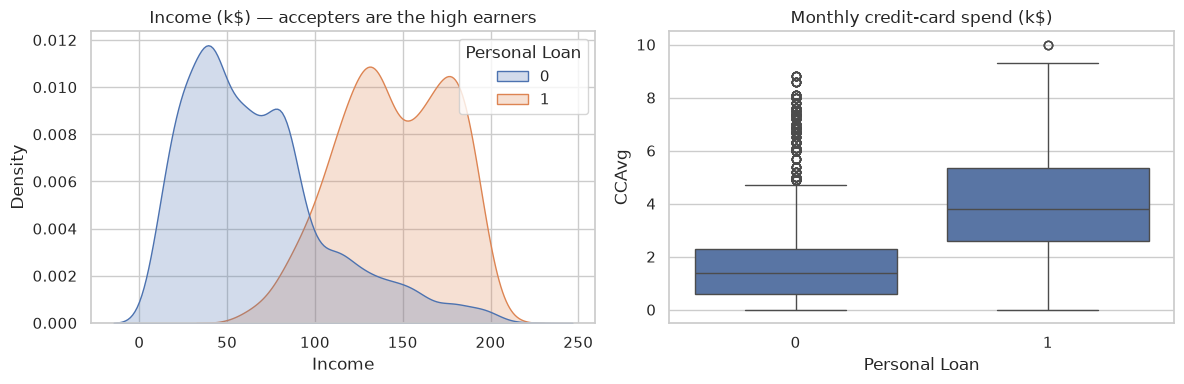

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(data=df, x="Income", hue=TARGET, common_norm=False, fill=True, ax=axes[0])
axes[0].set_title("Income (k$) — accepters are the high earners")
sns.boxplot(data=df, x=TARGET, y="CCAvg", ax=axes[1])
axes[1].set_title("Monthly credit-card spend (k$)")
plt.tight_layout()

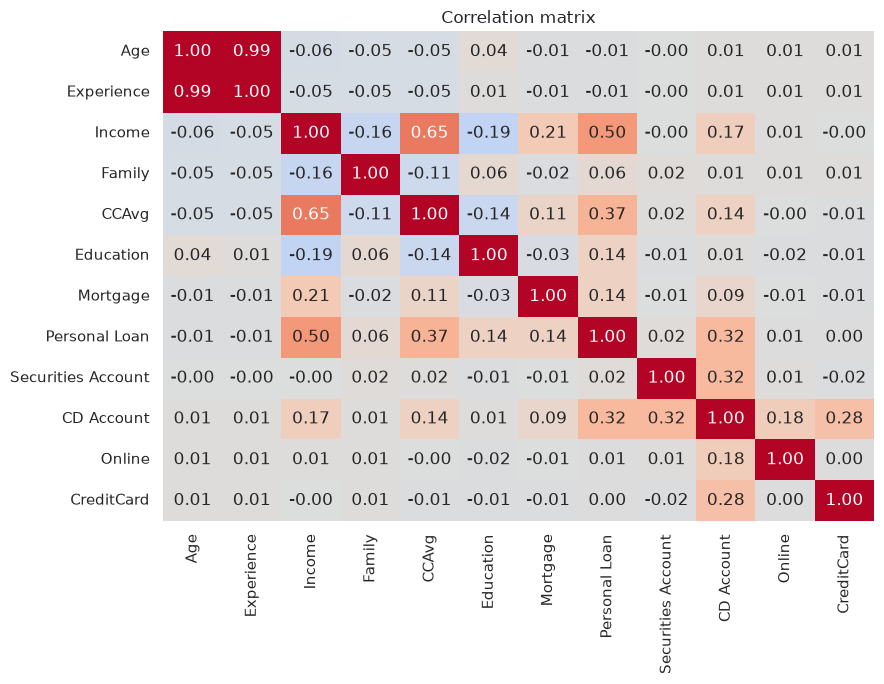

In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar=False)
plt.title("Correlation matrix")
plt.tight_layout()

Reading the figures:

- The income distributions barely overlap: below 80 k the acceptance rate is 0.2 %, above 120 k it is 42 %.
  A cut on income alone would already quadruple last year's conversion.
- `Age` and `Experience` are a duplicate pair (r = 0.99) and neither correlates with the target — the
  bank's intuition that "older = safer loan customer" is not in the data.
- Nothing correlates strongly *with each other* except Age/Experience, so multicollinearity is not a
  concern for the linear models.

## 4. Machine learning

Stratified 80/20 split, fixed seed. All metrics below are on the 20 % hold-out (1 000 customers)
the models never saw.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay,
                             precision_recall_curve)

X, y = df[FEATURES], df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f"train {len(X_train)}  test {len(X_test)}  test acceptance rate {y_test.mean():.1%}")

train 4000  test 1000  test acceptance rate 9.6%


### 4a. Baseline: multi-variable linear regression

The brief asks for a linear-regression baseline. We regress the 0/1 target on all features and call
a customer "will accept" when the fitted value is ≥ 0.5.

R² on test: 0.375
fitted values range: [-0.26, 0.84]


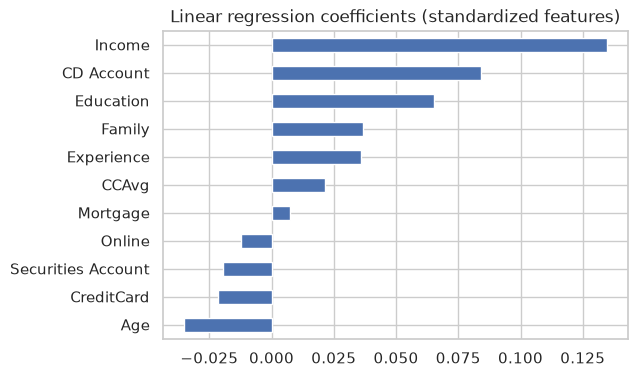

In [ ]:
linreg = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
lin_score = linreg.predict(X_test)
print(f"R² on test: {linreg.score(X_test, y_test):.3f}")
print(f"fitted values range: [{lin_score.min():.2f}, {lin_score.max():.2f}]")
coefs = pd.Series(linreg[-1].coef_, index=FEATURES).sort_values()
coefs.plot.barh(title="Linear regression coefficients (standardized features)", figsize=(6, 4));

The model explains only ~38 % of the variance, even though the coefficients tell a consistent story
(income, CD account, education, family size up; securities account, credit card down). It also
predicts negative "probabilities" for nearly a third of the customers and nothing stops it from exceeding 1
— it is fitting a *line* to a *yes/no* outcome. Its output is a score, not a probability, so a
marketing team could not read "0.3" as "30 % chance". That is exactly why we move to classifiers,
keeping this model as the reference to beat.

### 4b. Classifiers: logistic regression and random forest

- **Logistic regression** — the linear model done right for a binary target: bounded, calibrated
  probabilities, still fully interpretable.
- **Random forest** — non-linear; can learn the "income above X *and* education above Y" kind of
  rule the plots hint at. 300 trees, default depth.

In [ ]:
models = {
    "Linear regression (baseline)": linreg,
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_train, y_train),
    "Random forest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1).fit(X_train, y_train),
}

def scores(model):
    # Linear regression has no predict_proba: its fitted value plays the role of a score.
    return model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_test)

rows = []
for name, m in models.items():
    s = scores(m)
    pred = (s >= 0.5).astype(int)
    rows.append({"model": name,
                 "accuracy": accuracy_score(y_test, pred),
                 "precision": precision_score(y_test, pred),
                 "recall": recall_score(y_test, pred),
                 "F1": f1_score(y_test, pred),
                 "ROC-AUC": roc_auc_score(y_test, s)})
results = pd.DataFrame(rows).set_index("model")
results.style.format("{:.3f}").highlight_max(axis=0, color="#c6efce")

,accuracy,precision,recall,F1,ROC-AUC
model,,,,,
Linear regression (baseline),0.933,0.939,0.323,0.481,0.958
Logistic regression,0.954,0.829,0.656,0.733,0.964
Random forest,0.995,0.979,0.969,0.974,0.999


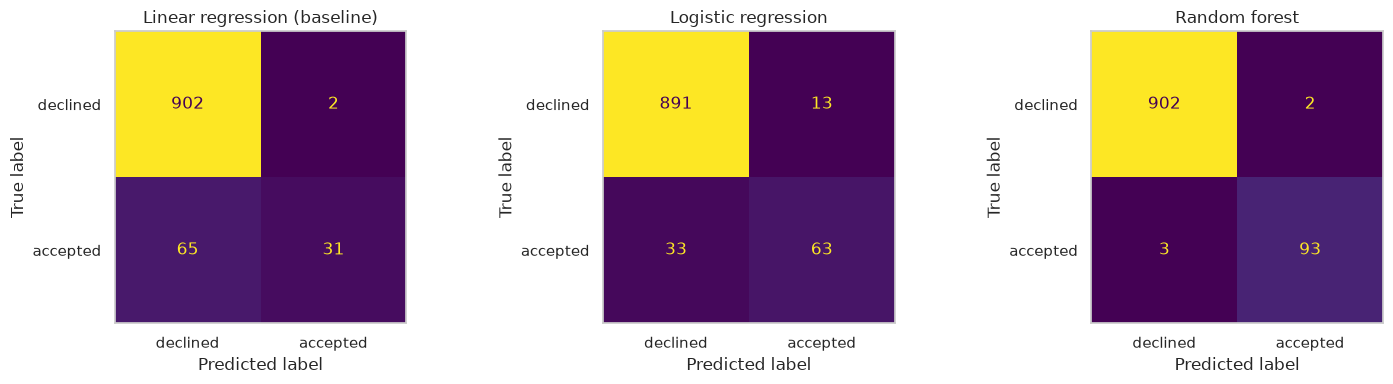

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, m) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, (scores(m) >= 0.5).astype(int), ax=ax, colorbar=False,
                                            display_labels=["declined", "accepted"])
    ax.set_title(name); ax.grid(False)
plt.tight_layout()

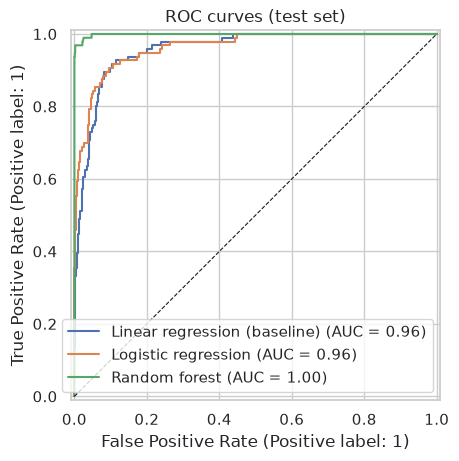

In [ ]:
ax = plt.gca()
for name, m in models.items():
    RocCurveDisplay.from_predictions(y_test, scores(m), name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_title("ROC curves (test set)");

Accuracy is a trap here: predicting "nobody accepts" already scores 90 %. The numbers that matter
for a marketing campaign are **precision** (of the people we contact, how many accept) and
**recall** (of the people who would accept, how many we found).

- The linear baseline is precise (94 %) but nearly blind: it finds only a third of the accepters,
  because a line through a 90/10 target rarely crosses 0.5.
- Logistic regression doubles the recall (66 %) for the same linear signal — correct model family.
- The random forest is the clear winner: 99.5 % accuracy, 98 % precision, 97 % recall, 0.999 AUC.
  On 1 000 hold-out customers it misses 3 accepters and wastes 2 contacts.

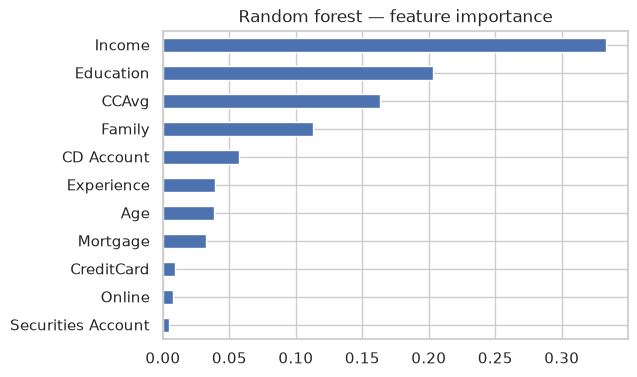

In [ ]:
rf = models["Random forest"]
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
importances.plot.barh(title="Random forest — feature importance", figsize=(6, 4));

The forest agrees with the exploration: **Income, Education, CCAvg, Family and CD Account** carry
87 % of the signal. Age, Experience, Mortgage and the online/credit-card/securities flags add
little — the bank could score customers from five fields.

### 4c. The threshold is a business knob

A classifier outputs a probability; *we* choose the cut-off. Lowering it contacts more people and
catches more accepters at the cost of more wasted contacts.

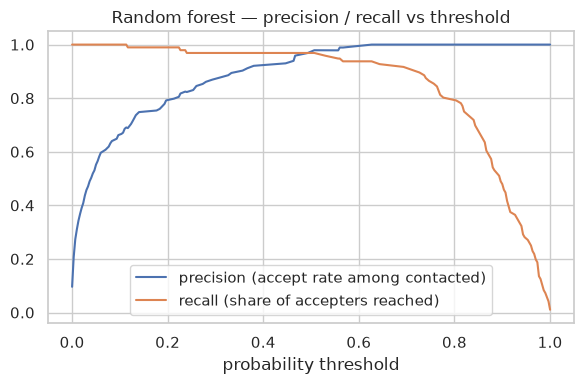

In [ ]:
rf_score = scores(rf)
prec, rec, thr = precision_recall_curve(y_test, rf_score)
plt.figure(figsize=(6, 4))
plt.plot(thr, prec[:-1], label="precision (accept rate among contacted)")
plt.plot(thr, rec[:-1], label="recall (share of accepters reached)")
plt.xlabel("probability threshold"); plt.legend(); plt.title("Random forest — precision / recall vs threshold")
plt.tight_layout()

## 5. Communication — what happens to the conversion rate?

The marketing question is not "is the model accurate" but "**if we only contact the customers the
model ranks highest, what conversion rate do we get?**" We simulate that on the 1 000 hold-out
customers: sort them by predicted probability and contact the top 10 %, 20 %, 30 %.

In [ ]:
sim = pd.DataFrame({"y": y_test.values, "score": rf_score}).sort_values("score", ascending=False)
sim["contacted"] = np.arange(1, len(sim) + 1)
sim["cum_accepters"] = sim["y"].cumsum()
sim["conversion"] = sim["cum_accepters"] / sim["contacted"]
sim["share_of_accepters"] = sim["cum_accepters"] / sim["y"].sum()

campaign = pd.DataFrame({
    "contact top": ["10 %", "20 %", "30 %", "everyone (last year)"],
    "customers contacted": [100, 200, 300, len(sim)],
})
campaign["accepters reached"] = [int(sim["cum_accepters"].iloc[n - 1]) for n in campaign["customers contacted"]]
campaign["conversion rate"] = campaign["accepters reached"] / campaign["customers contacted"]
campaign["share of all accepters"] = campaign["accepters reached"] / sim["y"].sum()
campaign.style.format({"conversion rate": "{:.1%}", "share of all accepters": "{:.0%}"}).hide(axis="index")

contact top,customers contacted,accepters reached,conversion rate,share of all accepters
10 %,100,93,93.0%,97%
20 %,200,96,48.0%,100%
30 %,300,96,32.0%,100%
everyone (last year),1000,96,9.6%,100%


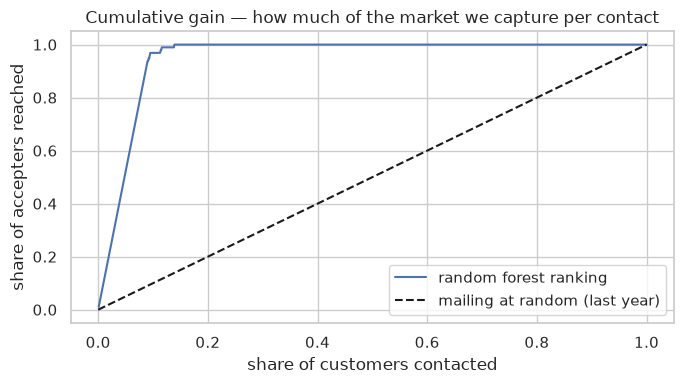

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
frac = sim["contacted"] / len(sim)
ax.plot(frac, sim["share_of_accepters"], label="random forest ranking")
ax.plot([0, 1], [0, 1], "k--", label="mailing at random (last year)")
ax.set_xlabel("share of customers contacted"); ax.set_ylabel("share of accepters reached")
ax.set_title("Cumulative gain — how much of the market we capture per contact")
ax.legend(); plt.tight_layout()

### Expected impact

- Contacting only the **top 10 %** of customers the model ranks converts at **93 %** instead of
  9.6 % — ten times better — and already reaches 97 % of everyone who would have accepted.
- Every single accepter in the hold-out sits in the top 14 % of the ranking; contacting the top 20 %
  still converts at 48 % with nothing left on the table.
- Put differently: last year's budget contacted 5 000 people to win ~480 loans. The same ~480 loans
  are reachable with ~700 targeted contacts. Marketing spend drops ~7× for the same revenue, or the
  same spend funds a much larger prospect pool.

### Risks and assumptions the CEO should hear

- **The model learns *last year's* campaign.** Whoever was offered a loan then, and how, shapes the
  labels. If the next campaign changes the offer (rate, amount, channel) the historical probabilities
  may not transfer. Re-train after each campaign; monitor the realised conversion against the
  predicted one.
- **False negatives are silent.** Customers the model skips are never asked, so we never learn we
  were wrong about them. Keep a small random control group in every campaign — it is the only way to
  measure the lift honestly and to keep the training data unbiased.
- **False positives cost money and goodwill.** At the 10 % cut ~1 in 14 contacts is wasted, at the
  20 % cut every second one; cheap for email, expensive for a phone campaign. Pick the threshold per channel with the precision/recall
  curve above.
- **Fairness and regulation.** Income and education dominate. That is legitimate for a loan
  *offer*, but the same score must not silently become a loan *decision*, and Age/Experience (near-zero
  importance anyway) should be excluded from any model that touches eligibility.
- **Correlation, not causation.** CD-account holders accept 6× more often — offering CD accounts
  will not create loan customers. Use the flag to *find* good prospects, not to *make* them.
- **Small data.** 480 positive examples. The forest's 99 % is real on this hold-out, but expect a
  few points of decay in production; the logistic model is the safer fallback if the forest drifts.

## 6. Production code

`loan_model.py` next to this notebook wraps the winning pipeline for the DevOps team:

```
uv run loan_model.py train data/Visa_For_Lisa_Loan_Modelling.csv   # fits, evaluates, writes model.joblib
uv run loan_model.py predict new_customers.csv                       # prints one probability per row
uv run pytest                                                        # 2 smoke tests
```

It applies the same cleaning as section 1 (drops `ID`/`ZIP Code`, absolute `Experience`) inside the
pipeline so raw exports from the bank's system can be scored directly. The cell below fits that module's
pipeline on the same training rows and scores the same hold-out, to prove the two agree.

In [ ]:
import loan_model
prod_model = loan_model.build_pipeline(seed=SEED).fit(raw.loc[X_train.index], y_train)
prod_pred = loan_model.predict(prod_model, raw.loc[X_test.index])
print(f"production pipeline AUC on the same hold-out: {roc_auc_score(y_test, prod_pred):.4f}")
assert np.allclose(prod_pred, rf_score), "loan_model.py must reproduce the notebook's forest exactly"

production pipeline AUC on the same hold-out: 0.9990


## 7. Slides

---
### Slide 1 — Visa For Lisa
Turning Galaxy Bank's depositors into loan customers with targeted marketing.

---
### Slide 2 — Where we start
- 5 000 deposit customers, 13 attributes, last campaign converted **9.6 %**.
- Mailing everyone: 5 000 contacts → ~480 loans.

---
### Slide 3 — Who says yes
- Income is the story: accepters earn ~2.5× more (median 142 k vs 59 k) and spend 2.5× more on their card.
- Graduate / professional education: 3× the acceptance of undergraduates.

---
### Slide 4 — The strongest single flag
- Customers with a **CD account** accept 46 % of the time vs 7 % without.
- Age, experience, mortgage, online banking and credit card: no signal.

---
### Slide 5 — Models
| model | precision | recall | AUC |
|---|---|---|---|
| linear regression (baseline) | 0.94 | 0.32 | 0.958 |
| logistic regression | 0.83 | 0.66 | 0.964 |
| **random forest** | **0.98** | **0.97** | **0.999** |

---
### Slide 6 — What happens to the conversion rate
- Contact the **top 10 %** the model ranks → **93 % conversion**, 97 % of all accepters reached.
- Every accepter is in the top 14 %: same ~480 loans for ~700 contacts instead of 5 000.

---
### Slide 7 — Risks
- Model reflects last year's offer → re-train after every campaign, keep a random control group.
- Income/education drive the score → fine for an *offer*, never for a loan *decision*.
- CD account correlates, doesn't cause.

---
### Slide 8 — Recommendation
- Ship the random-forest ranking (`loan_model.py`), contact the top 10–20 % per channel.
- Hold out 5 % at random to measure real lift; review after one campaign.